In [1]:
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
import pandas as pd
import numpy as np

In [2]:
x=pd.read_csv(r"C:\Temp\Heart-Failure-Prediction\x.csv")
y=pd.read_csv(r"C:\Temp\Heart-Failure-Prediction\y.csv")
x_rus=pd.read_csv(r"C:\Temp\Heart-Failure-Prediction\x_rus.csv")
y_rus=pd.read_csv(r"C:\Temp\Heart-Failure-Prediction\y_rus.csv")
x_ros=pd.read_csv(r"C:\Temp\Heart-Failure-Prediction\x_ros.csv")
y_ros=pd.read_csv(r"C:\Temp\Heart-Failure-Prediction\y_ros.csv")
x_smt=pd.read_csv(r"C:\Temp\Heart-Failure-Prediction\x_smt.csv")
y_smt=pd.read_csv(r"C:\Temp\Heart-Failure-Prediction\y_smt.csv")
x_ada=pd.read_csv(r"C:\Temp\Heart-Failure-Prediction\x_ada.csv")
y_ada=pd.read_csv(r"C:\Temp\Heart-Failure-Prediction\y_ada.csv")

In [238]:
y_rus

,DEATH_EVENT
0,0
1,0
2,0
3,0
4,0
...,...
187,1
188,1
189,1
190,1


In [94]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x_smt,y_smt, test_size = 0.2, random_state=42)

In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [85]:
y_test = y_test.values.ravel()
y_train = y_train.values.ravel()


In [96]:
model=keras.Sequential([
    Dense(30, activation='relu', input_shape=(12,)),
    Dropout(0.1),
    Dense(15,activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')      
    
    
])
model.summary()

c:\Temp\Heart-Failure-Prediction\tf-venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_88 (Dense)                │ (None, 30)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 871 (3.40 KB)

 Trainable params: 871 (3.40 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [98]:
model_=model.fit(x_train_scaled, y_train, epochs=50, validation_data=(x_test_scaled, y_test))

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5772 - loss: 0.6964 - val_accuracy: 0.6098 - val_loss: 0.6533
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6080 - loss: 0.6490 - val_accuracy: 0.6829 - val_loss: 0.6269
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6543 - loss: 0.6233 - val_accuracy: 0.7195 - val_loss: 0.6047
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7222 - loss: 0.5704 - val_accuracy: 0.7927 - val_loss: 0.5842
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7253 - loss: 0.5691 - val_accuracy: 0.7805 - val_loss: 0.5627
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7963 - loss: 0.5392 - val_accuracy: 0.7927 - val_loss: 0.5410
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7809 - loss: 0.5273 - val_accuracy: 0.8171 - val_loss: 0.5223
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8117 - loss: 0.5073 - val_accuracy: 0.8049 - val_lo

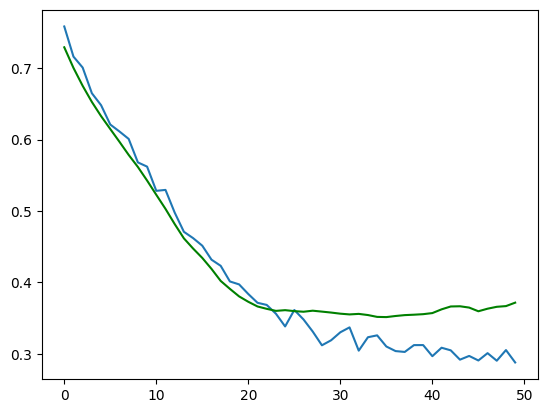

In [19]:
import matplotlib.pyplot as plt 

plt.plot(model_.history['loss'])
plt.plot(model_.history['val_loss'], color='g')

accuracy: 0.8654 - loss: 0.3464 - val_accuracy: 0.8415 -- ada data with simple mlp
[[29  5]
 [ 8 40]]

 -----------------------------------------------------------
 accuracy: 0.8287 - loss: 0.4033 - val_accuracy: 0.8415 -- ada 30 first layer with 0.5 droupout -- 

 -----------------------------
 accuracy: 0.8704 - loss: 0.3757 - val_accuracy: 0.8659 -- ros 
[[33  8]
 [ 3 38]]
 ---------------------------------------------
 SMOT
 -->  accuracy: 0.8981 - loss: 0.2225 - val_accuracy: 0.8780
 --> 50 epochs
 --> 30 (relu) -- 15 (relu) -- output (sigmoid)
 --> adam
 --> [[35  6]
     [ 4 37]]
-------------------
 SMOT
 -->  accuracy: 0.8951 - loss: 0.2425 - val_accuracy: 0.8780
 --> 50 epochs
 --> 30 (relu) -- droupout (0.1) -- 15 (relu) -- output (sigmoid)
 --> adam
 --> [[36  5]
     [ 5 36]]
-------------------
 SMOT
 -->  accuracy: 0.8858 - loss: 0.2880 - val_accuracy: 0.9024 
 --> 50 epochs
 --> 30 (relu) -- droupout (0.1) -- 15 (relu) -- droupout(0.1)-- output (sigmoid)
 --> adam
 -->[[36  5]
    [ 3 38]]


In [20]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = model.predict(x_test_scaled)
y_pred_ = (y_pred > 0.5).astype(int).ravel()

cm = confusion_matrix(y_test, y_pred_)
print(cm)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[[36  5]
 [ 3 38]]


In [21]:
from sklearn.metrics import classification_report
classr=classification_report(y_pred_,y_test)
print(classr)

              precision    recall  f1-score   support

           0       0.88      0.92      0.90        39
           1       0.93      0.88      0.90        43

    accuracy                           0.90        82
   macro avg       0.90      0.90      0.90        82
weighted avg       0.90      0.90      0.90        82

